In [113]:
# %matplotlib inline

# Standard numerical and visualization libraries
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

SMALL_SIZE  = 16
MEDIUM_SIZE = 20
BIGGER_SIZE = 24
MSU_GREEN   = "#18453B" 

matplotlib.rc('font',   size=SMALL_SIZE)          # controls default text sizes
matplotlib.rc('axes',   titlesize=MEDIUM_SIZE)    # fontsize of the axes title
matplotlib.rc('axes',   labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
matplotlib.rc('xtick',  labelsize=SMALL_SIZE)     # fontsize of the tick labels
matplotlib.rc('ytick',  labelsize=SMALL_SIZE)     # fontsize of the tick labels
matplotlib.rc('legend', fontsize=SMALL_SIZE)      # legend fontsize
matplotlib.rc('figure', titlesize=BIGGER_SIZE)    # fontsize of the figure title

# 1-D Hydrodynamics Solver

This notebook implements a finite-volume hydrodynamics solver for the **1D Euler equations** and validates it against the exact solution of Sod's shock tube problem (see Zingale Figs. 8.9 and 8.10).

Sod's shock tube is the canonical test problem for 1D compressible solvers. The domain starts with a high-pressure left state and a low-pressure right state separated by a membrane at $x = 0.5$.

---

## The 1D Euler Equations

The Euler equations express conservation of mass, momentum, and energy in conservative form:

$$
\mathcal{U}_t + \left[\mathbf{F}(\mathcal{U})\right]_x = 0
$$

with conserved variable vector $\mathcal{U}$ and flux vector $\mathbf{F}$:

$$
\mathcal{U} =
\begin{bmatrix}
\rho \\ \rho u \\ \rho E
\end{bmatrix}

\qquad\qquad

\mathbf{F}(\mathcal{U}) =
\begin{bmatrix}
\rho u \\ \rho u^2 + p \\ u(\rho E + p)
\end{bmatrix}
$$

The **conserved variables** are:

- mass density: $\rho(x,t)$
- momentum density: $\rho u(x,t)$
- total energy density: $\rho E(x,t)$

The **primitive (physical) variables** are:

- density: $\rho(x,t)$
- velocity: $u(x,t)$
- pressure: $p(x,t)$

---

## Energetics and Equation of State

$E$ is the **specific total energy** (energy per unit mass):

$$
E = e + \frac{1}{2} u^2
$$

where $e$ is the specific internal energy. The system is closed by the **gamma-law equation of state**:

$$
p = \rho e (\gamma - 1)
$$

where $\gamma$ is the ratio of specific heats.

---

## Sod Problem Initial Conditions

For the Sod problem (Zingale §8.9.1) we use $\gamma = 1.4$ and:

$$
\begin{align*}
\rho_L = 1 \qquad & \qquad \rho_R = 1/8 \\
u_L = 0 \qquad & \qquad u_R = 0 \\
p_L = 1 \qquad & \qquad p_R = 1/10
\end{align*}
$$

In [114]:
# Ghost cells pad the domain edges so the interior update stencil never accesses out-of-bounds
# indices. nghost=2 is sufficient for PLM.
nghost = 2

# The 1D Euler system carries 3 conserved variables: density (ρ), momentum density (ρu),
# and total energy density (ρE).
DOFs_sod = 3

In [115]:
def sods_shock_tube_IC(x, gamma):
    '''
    Definition: returns the conserved-variable state vector for Sod's shock tube at a single point x

    Inputs:     x     : spatial coordinate in [0, 1]
                gamma : adiabatic index (ratio of specific heats)

    Outputs:    U_element : conserved state (ρ, ρu, ρE)^T at point x

    Dependencies: none

    The Sod problem is a left-right membrane (discontinuity at x = 0.5):
        Left  state (x < 0.5) : ρ_L = 1,   u_L = 0, p_L = 1
        Right state (x ≥ 0.5) : ρ_R = 1/8, u_R = 0, p_R = 1/10

    The conserved variables are assembled as:
        ρ    = ρ_init
        ρu   = ρ_init * u_init
        ρE   = p/(γ-1) + ½ρu²     (total energy density from gamma-law EOS)
    '''
    if 0 <= x < 0.5:
        # Left state: high pressure, high density
        rho_init = 1
        u_init   = 0
        p_init   = 1
    elif 0.5 <= x <= 1:
        # Right state: low pressure, low density
        rho_init = 1/8
        u_init   = 0
        p_init   = 1/10
    else:
        print('error in sod IC')

    # Convert primitive variables to conserved form
    rho   = rho_init
    rho_u = rho_init * u_init
    rho_E = p_init/(gamma - 1) + 0.5*rho*u_init*u_init  # total energy density: ρE = p/(γ-1) + ½ρu²

    U_element = np.array([rho, rho_u, rho_E])
    return U_element

In [116]:
def fill_ghost_outflow_bc(U, nx):
    '''
    Definition: fills ghost cells with outflow (zero-gradient) boundary conditions

    Inputs:     U  : solution array of shape (DOFs, nx + 2*nghost) — modified in place
                nx : number of interior cells

    Outputs:    U  : same array with ghost cells set equal to the nearest interior cell value

    Dependencies: nghost
    
    Outflow BC sets each ghost cell equal to the adjacent interior edge value:
        left  ghosts : U[:, 0:nghost]        = U[:, nghost]        (nearest left  interior cell)
        right ghosts : U[:, nghost+nx:]      = U[:, nghost+nx-1]   (nearest right interior cell)

    This zero-gradient condition lets waves exit the domain without spurious reflections.
    Interior indices run from nghost to nghost+nx-1 (inclusive).
    '''
    for i in range(DOFs_sod):
        # Left boundary: copy leftmost interior cell into left ghost cells
        U[i, 0:nghost] = U[i, nghost]

        # Right boundary: copy rightmost interior cell into right ghost cells
        U[i, nghost+nx:] = U[i, nghost+nx-1]

    return U

In [117]:
def cons_to_prim(U, gamma):
    '''
    Definition: converts conserved variables to primitive variables

    Inputs:     U     : conserved state (ρ, ρu, ρE)^T
                gamma : adiabatic index

    Outputs:    U_prim : primitive state (ρ, u, p)^T

    Dependencies: none

    Conversion:
        u = (ρu) / ρ                          (velocity from momentum density)
        E = (ρE) / ρ                          (specific total energy)
        e = E - ½u²                           (specific internal energy)
        p = ρ e (γ - 1)                       (pressure from gamma-law EOS)
    '''
    # Grab conservative variables
    rho_cons   = U[0]
    rho_u_cons = U[1]
    rho_E_cons = U[2]

    # New solution vector to return
    U_prim = np.zeros_like(U)

    # Recover primitive variables
    rho_prim = rho_cons
    u_prim   = rho_u_cons / rho_cons              # velocity
    E_prim   = rho_E_cons / rho_cons              # specific total energy
    e_prim   = E_prim - 0.5*u_prim*u_prim         # specific internal energy
    p_prim   = rho_prim * e_prim * (gamma - 1)    # gamma-law pressure

    # Assign primitive variables to output vector
    U_prim[0] = rho_prim
    U_prim[1] = u_prim
    U_prim[2] = p_prim

    return U_prim


def prim_to_cons(U, gamma):
    '''
    Definition: converts primitive variables to conserved variables

    Inputs:     U     : primitive state (ρ, u, p)^T
                gamma : adiabatic index

    Outputs:    U_cons : conserved state (ρ, ρu, ρE)^T

    Dependencies: none

    Conversion:
        ρu  = ρ * u                            (momentum density)
        ρE  = p/(γ-1) + ½ρu²                  (total energy density from gamma-law EOS)
    '''
    # Grab primitive variables
    rho_prim = U[0]
    u_prim   = U[1]
    p_prim   = U[2]

    # New solution vector to return
    U_cons = np.zeros_like(U)

    # Assemble conserved variables
    rho_cons   = rho_prim
    rho_u_cons = rho_prim * u_prim                          # momentum density
    rho_E_cons = p_prim/(gamma-1) + 0.5*rho_prim*(u_prim**2)  # total energy density

    # Assign conserved variables to output vector
    U_cons[0] = rho_cons
    U_cons[1] = rho_u_cons
    U_cons[2] = rho_E_cons

    return U_cons

In [118]:
def compute_flux(q, gamma):
    '''
    Definition: evaluates the Euler flux vector F(U) at a single cell

    Inputs:     q     : conserved state (ρ, ρu, ρE)^T
                gamma : adiabatic index

    Outputs:    F : Euler flux vector (ρu, ρu²+p, u(ρE+p))^T

        F[0] = ρu                  (mass flux)
        F[1] = ρu² + p             (momentum flux)
        F[2] = u(ρE + p)           (energy flux, expanded as u·p/(γ-1) + ½ρu³ + up)

    Dependencies: cons_to_prim

    Reference: Zingale eq. 8.55
    '''
    q_prim = cons_to_prim(q, gamma)  # convert to primitive for easier flux evaluation

    rho = q_prim[0]
    u   = q_prim[1]
    p   = q_prim[2]

    F = np.zeros_like(q)
    F[0] = rho * u                                        # mass flux
    F[1] = rho * u*u + p                                  # momentum flux
    F[2] = u*p / (gamma -1) + 0.5*rho *(u*u*u) + u*p     # energy flux = u*(ρE + p)

    return F

# HLL Riemann Solver

At each cell interface, the finite-volume update requires the numerical flux $F_{i+1/2}$. The exact Riemann problem at that interface has a complex multi-wave fan solution. An **approximate Riemann solver** replaces this fan with a simpler, cheaper wave structure that still satisfies the integral form of the conservation law.

## Two-Wave (HLL) Approximation

The **HLL solver** (Harten, Lax, van Leer) represents the Riemann fan with just two bounding waves — a leftmost wave $S_L$ and a rightmost wave $S_R$ — enclosing a single averaged intermediate state $\mathcal{U}_{hll}$:

```
          t
          ^
          |
   S_L    |    S_R
     \    |    /
      \   |   /
       \  |  /
  U_L   \ | /   U_R
          \|/
  ---------+----------> x
           0
```

The two wave speeds are estimated from the left/right sound speeds $c_{L,R} = \sqrt{\gamma p / \rho}$:

$$S_L = \min(u_L - c_L,\; u_R - c_R), \qquad S_R = \max(u_L + c_L,\; u_R + c_R)$$

The HLL flux is then:

$$
F_{hll} =
\begin{cases}
F_L & \text{if } S_L \geq 0  \\
F_R & \text{if } S_R \leq 0  \\
\dfrac{S_R F_L - S_L F_R + S_L S_R (U_R - U_L)}{S_R - S_L} & \text{otherwise} 
\end{cases}
$$


*Modeled after Carolyn Wendeln's MHD implementation.*

In [119]:
def Riemann_HLL(U_L, U_R, gamma):
    '''
    Definition: computes the HLL approximate Riemann flux for the 1D Euler equations

    Inputs:     U_L   : left  conserved state (ρ, ρu, ρE)^T
                U_R   : right conserved state (ρ, ρu, ρE)^T
                gamma : adiabatic index

    Outputs:    flux : HLL flux vector (ρu, ρu²+p, u(ρE+p))^T at the interface

    Dependencies: cons_to_prim, compute_flux

    Reference: Toro, Riemann Solvers and Numerical Methods for Fluid Dynamics,
               Chapter 10 — The HLL and HLLC Riemann Solvers
    '''

    ################################################################################################
    # 1) Convert to primitive variables for wave-speed estimation
    ################################################################################################

    U_L_prim = cons_to_prim(U_L, gamma)
    U_R_prim = cons_to_prim(U_R, gamma)

    rho_L = U_L_prim[0]
    u_L   = U_L_prim[1]
    p_L   = U_L_prim[2]

    rho_R = U_R_prim[0]
    u_R   = U_R_prim[1]
    p_R   = U_R_prim[2]

    ################################################################################################
    # 2) Compute left and right sound speeds  c = sqrt(γp/ρ)
    ################################################################################################

    c_L = np.sqrt(gamma*p_L/rho_L)
    c_R = np.sqrt(gamma*p_R/rho_R)

    ################################################################################################
    # 3) Estimate bounding wave speeds 
    #    S_L = min(u_L - c_L, u_R - c_R)   
    #    S_R = max(u_L + c_L, u_R + c_R)   
    ################################################################################################

    s_l = min(u_L - c_L, u_R - c_R)
    s_r = max(u_L + c_L, u_R + c_R)

    ################################################################################################
    # 4) Evaluate physical fluxes F_L and F_R at the left and right states
    ################################################################################################

    F_L = compute_flux(U_L, gamma)
    F_R = compute_flux(U_R, gamma)

    ################################################################################################
    # 5) Determine the HLL Flux (Equation 10.21)
    ################################################################################################

    if s_l >= 0:
        flux = F_L
    elif s_r <= 0:
        flux = F_R
    else:
        flux = (s_r * F_L - s_l * F_R + s_l * s_r * (U_R - U_L)) / (s_r - s_l)

    return flux

# HLLC Riemann Solver

*Described in Toro Chapter 10*

The four regions separated by $S_L$, $S^*$, and $S_R$ are:
- **Left state** $U_L$ (for $x/t < S_L$)
- **Left star state** $U^*_L$ (for $S_L \leq x/t < S^*$)
- **Right star state** $U^*_R$ (for $S^* \leq x/t < S_R$)
- **Right state** $U_R$ (for $x/t \geq S_R$)

## Contact Wave Speed $S^*$

The contact wave speed is derived by enforcing conservation across the intermediate region (Toro eq. 10.37):

$$
S^* = \frac{p_R - p_L + \rho_L u_L (S_L - u_L) - \rho_R u_R (S_R - u_R)}{\rho_L(S_L - u_L) - \rho_R(S_R - u_R)}
$$

The HLLC intermediate states $U^*_{L,R}$ are constructed to satisfy the Rankine-Hugoniot jump conditions across $S_L$ and $S_R$ while having velocity $u = S^*$ and a consistent pressure across the contact (Toro eq. 10.39).

*Reference: Toro, Riemann Solvers and Numerical Methods for Fluid Dynamics,Chapter 10*

In [120]:
def U_star_s(U_s, rho_s, u_s, p_s, E_s, S_s, S_star):
    '''
    Definition: computes the HLLC intermediate (star) state vector on one side of the contact wave

    Inputs:     U_s    : conserved state on side s — (ρ, ρu, ρE)^T
                rho_s  : density on side s
                u_s    : velocity on side s
                p_s    : pressure on side s
                E_s    : total energy density (ρE) on side s
                S_s    : bounding wave speed on side s (S_L or S_R)
                S_star : contact wave speed S*

    Outputs:    U_star_s : HLLC intermediate conserved state (ρ*, ρ*S*, ρ*E*)^T

    Dependencies: none

    Reference: Toro eq. 10.39
    '''
    U_star_s = np.zeros_like(U_s)

    factor = rho_s * (S_s - u_s)/(S_s - S_star)  #  scaling factor (Toro eq. 10.39)

    U_star_s[0] = factor                           # ρ* = ρ (S_s - u_s)/(S_s - S*)
    U_star_s[1] = factor * S_star                  # ρ*u* = ρ* · S*   (velocity equals contact speed)
    U_star_s[2] = factor * (E_s/rho_s + (S_star - u_s)*(S_star + p_s/(rho_s*(S_s - u_s))))  # ρ*E* (Toro eq. 10.39)

    return U_star_s


def Riemann_HLLC(U_L, U_R, gamma):
    '''
    Definition: computes the HLLC approximate Riemann flux for the 1D Euler equations

    Inputs:     U_L   : left  conserved state (ρ, ρu, ρE)^T
                U_R   : right conserved state (ρ, ρu, ρE)^T
                gamma : adiabatic index

    Outputs:    flux : HLLC flux vector (ρu, ρu²+p, u(ρE+p))^T at the interface

    Dependencies: cons_to_prim, compute_flux, U_star_s

    Reference: Toro, Riemann Solvers and Numerical Methods for Fluid Dynamics,
                eq. 10.37 (S*), eq. 10.38 (F* from F and U*), eq. 10.39 (U*)
    '''

    ################################################################################################
    # 1) Convert to primitive variables for wave-speed estimation
    ################################################################################################

    U_L_prim = cons_to_prim(U_L, gamma)
    U_R_prim = cons_to_prim(U_R, gamma)

    rho_L = U_L_prim[0]
    u_L   = U_L_prim[1]
    p_L   = U_L_prim[2]

    rho_R = U_R_prim[0]
    u_R   = U_R_prim[1]
    p_R   = U_R_prim[2]

    ################################################################################################
    # 2) Compute left and right sound speeds  c = sqrt(γp/ρ)
    ################################################################################################

    c_L = np.sqrt(gamma*p_L/rho_L)
    c_R = np.sqrt(gamma*p_R/rho_R)

    ################################################################################################
    # 3) Estimate bounding wave speeds S_L, S_R and contact speed S*
    ################################################################################################

    S_L    = min(u_L - c_L, u_R - c_R)   # leftmost wave speed
    S_R    = max(u_L + c_L, u_R + c_R)   # rightmost wave speed
    S_star = (p_R - p_L + rho_L * u_L * (S_L - u_L) - rho_R * u_R * (S_R - u_R)) / \
            (rho_L*(S_L-u_L) - rho_R*(S_R-u_R))   # contact wave speed (Toro eq. 10.37)

    ################################################################################################
    # 4) Evaluate physical fluxes F_L and F_R at the original left and right states
    ################################################################################################

    F_L = compute_flux(U_L, gamma)
    F_R = compute_flux(U_R, gamma)

    ################################################################################################
    # 5) Compute HLLC star states U*_L, U*_R and their fluxes F*_L, F*_R
    #    F* = F_s + S_s*(U*_s - U_s)   (Toro eq. 10.38)
    ################################################################################################

    rho_E_L = U_L[2]   # total energy density on left
    rho_E_R = U_R[2]   # total energy density on right

    U_star_L = U_star_s(U_L, rho_L, u_L, p_L, rho_E_L, S_L, S_star)
    F_star_L = F_L + S_L*(U_star_L - U_L)   # HLLC flux in left star region (Toro eq. 10.38)

    U_star_R = U_star_s(U_R, rho_R, u_R, p_R, rho_E_R, S_R, S_star)
    F_star_R = F_R + S_R*(U_star_R - U_R)   # HLLC flux in right star region (Toro eq. 10.38)

    ################################################################################################
    # 6) Select flux based on which region the interface x/t=0 falls in
    ################################################################################################

    if S_L >= 0:
        flux = F_L
    elif (S_L <= 0 <= S_star):
        flux = F_star_L
    elif (S_star <= 0 <= S_R):
        flux = F_star_R
    else:
        flux = F_R

    return flux

In [121]:
def piecewise_constant(U):
    '''
    Definition: first-order (piecewise constant) reconstruction

    Inputs:     U : conserved variable array of shape (DOFs, nx + 2*nghost)

    Outputs:    U_L, U_R : left and right interface state arrays, both equal to U

    Dependencies: none

    Each cell is assumed to hold a uniform value; the left and right states at every
    interface are just the cell-center values of the neighboring cells. This gives a
    first-order-accurate scheme.
    '''
    return U, U

In [122]:
def minmod(a, b):
    '''
    Definition: vectorized minmod slope limiter

    Inputs:     a, b : slope arrays (or scalars) — typically forward and backward differences

    Outputs:    limited slope: the smaller-magnitude value when a and b have the same sign, else 0

                b > 0       b = 0       b < 0
    -------------------------------------------------
    a > 0 |   min(a,b)       0           0
    a = 0 |      0           0           0
    a < 0 |      0           0      -min(|a|,|b|)

    Dependencies: none

    Minmod prevents new extrema from forming at reconstructed interfaces by returning zero
    slope whenever the forward and backward differences disagree in sign (i.e. near a local
    extremum). Vectorized so input can be array-valued (one entry per DOF).
    '''
    return 0.5 * (np.sign(a) + np.sign(b)) * np.minimum(np.abs(a), np.abs(b))


def compute_interface_states_PLM(U):
    '''
    Definition: second-order piecewise linear method (PLM) reconstruction — computes left/right
                interface states using slope-limited linear extrapolation within each cell

    Inputs:     U  : conserved variable array of shape (DOFs, nx + 2*nghost)


    Outputs:    U_L : left  interface state array of shape (DOFs, nx + 2*nghost)
                U_R : right interface state array of shape (DOFs, nx + 2*nghost)

    Dependencies: minmod, nghost 

    Algorithm for each interior cell i:
        dl    = U[:,i+1] - U[:,i]       (forward  difference — slope to the right of cell i)
        dr    = U[:,i]   - U[:,i-1]     (backward difference — slope to the left  of cell i)
        slope = minmod(dl, dr)           (limiter: picks the smaller slope, zero near extrema)
        U_L[:,i] = U[:,i] + 0.5*slope   (extrapolate to the right interface of cell i)
        U_R[:,i] = U[:,i] - 0.5*slope   (extrapolate to the left  interface of cell i)

    The Riemann solver then uses U_L[:,i] as the left state and U_R[:,i+1] as the right state
    at the i+1/2 interface.
    '''
    n   = len(U[0])
    U_L = np.zeros_like(U)
    U_R = np.zeros_like(U)

    for i in range(nghost - 1, n - nghost + 1):
        dl = U[:,i+1] - U[:,i]    # forward difference  (slope to the right of cell i)
        dr = U[:,i]   - U[:,i-1]  # backward difference (slope to the left  of cell i)

        slope = minmod(dl, dr)    # slope limiter: prevents oscillations near sharp gradients

        U_L[:,i] = U[:,i] + 0.5 * slope   # extrapolate to right face of cell i
        U_R[:,i] = U[:,i] - 0.5 * slope   # extrapolate to left  face of cell i

    return U_L, U_R


def piecewise_linear(U):
    '''
    Definition: wrapper that calls PLM reconstruction and returns left/right interface states

    Inputs:     U  : conserved variable array of shape (DOFs, nx + 2*nghost)
=

    Outputs:    U_L, U_R : left and right interface state arrays (see compute_interface_states_PLM)

    Dependencies: compute_interface_states_PLM
    '''
    U_L, U_R = compute_interface_states_PLM(U)
    return U_L, U_R

In [123]:
U = np.zeros((3,10))
U[0,:] = np.arange(0,10)
U[1,:] = np.arange(1,11)
U[2,:] = np.arange(2,12)

print(U)
print(np.roll(U,1,1))
print(U - np.roll(U,1,1))


[[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9.]
 [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
 [ 2.  3.  4.  5.  6.  7.  8.  9. 10. 11.]]
[[ 9.  0.  1.  2.  3.  4.  5.  6.  7.  8.]
 [10.  1.  2.  3.  4.  5.  6.  7.  8.  9.]
 [11.  2.  3.  4.  5.  6.  7.  8.  9. 10.]]
[[-9.  1.  1.  1.  1.  1.  1.  1.  1.  1.]
 [-9.  1.  1.  1.  1.  1.  1.  1.  1.  1.]
 [-9.  1.  1.  1.  1.  1.  1.  1.  1.  1.]]


## Heun's Method for RK2

\begin{align}
k_1 &= f_{t_i}(a_i) \tag{8.3.1.11a} \\
k_2 &= f_{t_i+h}(a_i + k_1 dt) \tag{8.3.1.11b} \\
a_{i+1} &= a_i + 0.5 dt (k1 + k2) \tag{8.3.1.10}
\end{align}

In [124]:
def f(U, nx, dx, gamma, Riemann):
    U_L, U_R = piecewise_linear(U)

    F = np.zeros_like(U)
    for i in range(nghost-1, nghost+nx):
        F[:,i] = Riemann(U_L[:, i], U_R[:, i+1], gamma)   # flux at interface i+1/2
        
    return -(F - np.roll(F,1,1))/dx # - (F(U_{i+1/2}) - F(U_{i-1/2}) / dx

def RK2_step(Riemann, U, nx, dx, dt, gamma):
    k1 = f(U, nx, dx, gamma, Riemann)                    
    U_star = U + dt * k1
    fill_ghost_outflow_bc(U_star, nx) #need this before reconstructing a again in k2

    k2 = f(U_star, nx, dx, gamma, Riemann)               
    U_next = U + 0.5 * dt * (k1 + k2)
    #fill_ghost_periodic_bc(a_next) # only need this if gonna use it before calling BCs in the main loop
    return U_next

In [125]:

def evolve(U_ghosted, nx, C, t_final, gamma, Riemann, Godunov_type, RK2=False):
    '''
    Definition: advances the 1D Euler equations forward in time using a Godunov finite-volume scheme

    Inputs:     U_ghosted    : initial ghosted conserved variable array of shape (DOFs, nx + 2*nghost)
                nx           : number of interior cells
                C            : CFL number — controls the time step size 
                t_final      : final simulation time
                gamma        : adiabatic index
                Riemann      : callable — approximate Riemann solver (Riemann_HLL or Riemann_HLLC)
                Godunov_type : reconstruction order
                            0 = piecewise constant (1st-order Godunov)
                            1 = piecewise linear with minmod limiter (2nd-order)

    Outputs:    U[:, nghost:nghost+nx] : final interior conserved state (DOFs, nx)
                all_solns              : list of interior snapshots (DOFs, nx) at each time step
                all_t                  : list of corresponding simulation times

    Dependencies: fill_ghost_outflow_bc, cons_to_prim, piecewise_constant, piecewise_linear, Riemann
    '''
    dx = 1.0 / nx

    U = U_ghosted.copy()

    all_solns = []  # stores snapshots of the interior solution for animation
    all_t     = []  # stores the time of each snapshot
    t = 0.0

    all_solns.append(U[:, nghost:nghost+nx].copy())
    all_t.append(t)

    while t < t_final:

        ############################################################################################
        # 1) Apply outflow boundary conditions to fill ghost cells
        ############################################################################################

        fill_ghost_outflow_bc(U, nx)

        ############################################################################################
        # 2) Estimate CFL-limited time step
        #    dt = C * dx / max|u + c|   where c = sqrt(γp/ρ) is the sound speed
        #    Also clip dt so we do not step past t_final
        ############################################################################################

        U_prim = cons_to_prim(U[:, nghost:nghost+nx], gamma)   # (ρ, u, p) over interior cells
        c  = np.sqrt(gamma * U_prim[2] / U_prim[0])            # local sound speed c = sqrt(γp/ρ)
        dt = C * dx / np.max(np.abs(U_prim[1]) + c)            # CFL condition: dt ≤ C·dx / max|u+c|
        dt = min(dt, t_final - t)                               # clip to land exactly on t_final

        if RK2:
            U = RK2_step(Riemann, U, nx, dx, dt, gamma)
            
        else:
            ############################################################################################
            # 3) Reconstruct left/right interface states using the chosen Godunov type
            ############################################################################################

            if Godunov_type == 0:   # piecewise constant: U_L = U, U_R = U (first order)
                U_L, U_R = piecewise_constant(U)
            if Godunov_type == 1:   # piecewise linear with minmod limiter (second order)
                U_L, U_R = piecewise_linear(U)

            ############################################################################################
            # 4) Evaluate the approximate Riemann solver at each interface i+1/2
            #    Riemann(U_L[:,i], U_R[:,i+1], gamma) → numerical flux F_{i+1/2}
            ############################################################################################

            F = np.zeros_like(U)

            for i in range(nghost-1, nghost+nx):
                F[:,i] = Riemann(U_L[:, i], U_R[:, i+1], gamma)   # flux at interface i+1/2

            ############################################################################################
            # 5) Conservative update: U_i^{n+1} = U_i^n - (dt/dx)(F_{i+1/2} - F_{i-1/2})
            ############################################################################################

            for i in range(nghost, nghost+nx):
                U[:, i] = U[:, i] - (dt/dx) * (F[:, i] - F[:, i-1])

        ############################################################################################
        # 6) Advance time and store interior snapshot for animation
        ############################################################################################

        t += dt

        all_solns.append(U[:, nghost:nghost+nx].copy())
        all_t.append(t)

    return U[:, nghost:nghost+nx], all_solns, all_t

In [126]:
def plot_solution(grid, U_Sol, t, gamma, case='Sod', Godonuv_type='Piecewise Constant', Riemann='HLL'):
    '''
    Definition: plots the numerical solution against the exact solution for a 1D Euler test case

    Inputs:     grid        : interior cell-center coordinate array of shape (nx,)
                U_Sol       : final conserved variable array (ρ, ρu, ρE)^T of shape (DOFs, nx)
                t           : final simulation time (used for plot title)
                gamma       : adiabatic index
                case        : name of the test case — used to load the matching exact solution file
                              from the exact_solutions/ directory (e.g. 'Sod')
                Godonuv_type: reconstruction label for the legend (e.g. 'Piecewise Linear')
                Riemann     : Riemann solver label for the legend (e.g. 'HLL' or 'HLLC')

    Outputs:    matplotlib figure with 2x2 subplots:
                  top-left    : density ρ
                  bottom-left : pressure p
                  top-right   : velocity u
                  bottom-right: total energy density ρE

                Exact solution (black solid line) is overlaid on the numerical result (MSU green dotted).

    Dependencies: cons_to_prim, MSU_GREEN (module-level constant)

    Exact solutions are pre-computed and stored as whitespace-delimited text files in exact_solutions/.
    Columns: x, ρ, vx, vy, vz, p, Bx, By, Bz, E  (MHD format; only x, ρ, vx, p, E used here).
    '''

    exact_grid, exact_rho, exact_vex, exact_vey, exact_vez, exact_pre, exact_Bx, exact_By, exact_Bz, exact_E = \
        np.loadtxt(f"exact_solutions/{case}.txt", unpack=True, skiprows=1)

    # Recover primitive and derived variables from the conserved solution
    rho_sol   = U_Sol[0]
    rho_u_sol = U_Sol[1]
    rho_E_sol = U_Sol[2]

    u_sol = rho_u_sol / rho_sol          # velocity
    E_sol = rho_E_sol / rho_sol          # specific total energy
    e_sol = E_sol - 0.5*u_sol*u_sol      # specific internal energy
    p_sol = rho_sol*e_sol*(gamma - 1)    # pressure from gamma-law EOS

    fig, plots = plt.subplots(2, 2, figsize=(18, 10), dpi=300)

    fig.suptitle(f'{case} Shock Tube at t = {t:.2f}')

    plt.rcParams['axes.grid']       = True
    plt.rcParams['grid.color']      = 'lavender'
    plt.rcParams['grid.linestyle']  = '-'
    plt.rcParams['grid.linewidth']  = 0.8

    CE = 'k'  # exact solution color (black)

    # Top Left: density
    plots[0][0].plot(exact_grid, exact_rho, color=CE, linestyle='-', linewidth=2, label='Exact')
    plots[0][0].plot(grid, rho_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5, label=f'{Godonuv_type} \n {Riemann}')
    plots[0][0].set_title('Density')
    plots[0][0].set_xlim([0,1])
    plots[0][0].legend()

    # Bottom Left: pressure
    plots[1][0].plot(exact_grid, exact_pre, color=CE, linestyle='-', linewidth=2)
    plots[1][0].plot(grid, p_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
    plots[1][0].set_title('Pressure')
    plots[1][0].set_xlim([0,1])

    # Top Right: velocity
    plots[0][1].plot(exact_grid, exact_vex, color=CE, linestyle='-', linewidth=2)
    plots[0][1].plot(grid, u_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
    plots[0][1].set_title(r'$v_x$')
    plots[0][1].set_xlim([0,1])

    # Bottom Right: total energy density ρE
    plots[1][1].plot(exact_grid, exact_E, color=CE, linestyle='-', linewidth=2)
    plots[1][1].plot(grid, rho_E_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
    plots[1][1].set_title('Total Energy')
    plots[1][1].set_xlim([0,1])

    # plt.savefig(f"{case}.png",dpi=200)

    plt.show()

In [127]:
def movie_maker(grid, all_solns, all_t, gamma, case):
    '''
    Definition: creates an animated GIF of the 1D Euler solution over time,
                showing density, pressure, velocity, and total energy density

    Inputs:     grid      : interior cell-center coordinate array of shape (nx,)
                all_solns : list of conserved variable snapshots (ρ, ρu, ρE)^T at each time step,
                            each of shape (DOFs, nx); produced by evolve()
                all_t     : list of simulation times corresponding to each snapshot in all_solns
                gamma     : adiabatic index
                case      : test case name — used for the plot title and output file name

    Outputs:    saves {case}.gif to the current directory at 30 fps via pillow

    Dependencies: MSU_GREEN 
    
    The inner animate(i) function is the per-frame callback for matplotlib's FuncAnimation.
    It clears and redraws all four subplots at frame i, comparing the numerical solution against
    the pre-computed exact solution loaded from exact_solutions/{case}.txt.
    '''

    n_steps = len(all_t)

    exact_grid, exact_rho, exact_vex, exact_vey, exact_vez, exact_pre, exact_Bx, exact_By, exact_Bz, exact_E = \
        np.loadtxt(f"exact_solutions/{case}.txt", unpack=True, skiprows=1)

    fig, plots = plt.subplots(2, 2, figsize=(18, 10), dpi=200)

    def animate(i):
        ''' per-frame update callback: clears and redraws all subplots for time step i '''

        plots[0][0].clear()
        plots[1][0].clear()
        plots[0][1].clear()
        plots[1][1].clear()

        t       = all_t[i]
        U_frame = all_solns[i]   # conserved state snapshot at time step i

        rho_sol   = U_frame[0]
        rho_u_sol = U_frame[1]
        rho_E_sol = U_frame[2]

        u_sol = rho_u_sol / rho_sol          # velocity
        E_sol = rho_E_sol / rho_sol          # specific total energy
        e_sol = E_sol - 0.5*u_sol*u_sol      # specific internal energy
        p_sol = rho_sol*e_sol*(gamma - 1)    # pressure from gamma-law EOS

        fig.suptitle(f'{case} Shock Tube at t = {t:.3f}')

        plt.rcParams['axes.grid']      = True
        plt.rcParams['grid.color']     = 'lavender'
        plt.rcParams['grid.linestyle'] = '-'
        plt.rcParams['grid.linewidth'] = 0.8

        CE = 'k'  # exact solution color (black)

        # Top Left: density
        plots[0][0].plot(exact_grid, exact_rho, color=CE, linestyle='-', linewidth=2)
        plots[0][0].plot(grid, rho_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
        plots[0][0].set_title('Density')
        plots[0][0].set_xlim([0,1])

        # Bottom Left: pressure
        plots[1][0].plot(exact_grid, exact_pre, color=CE, linestyle='-', linewidth=2)
        plots[1][0].plot(grid, p_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
        plots[1][0].set_title('Pressure')
        plots[1][0].set_xlim([0,1])

        # Top Right: velocity
        plots[0][1].plot(exact_grid, exact_vex, color=CE, linestyle='-', linewidth=2)
        plots[0][1].plot(grid, u_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
        plots[0][1].set_title(r'$v_x$')
        plots[0][1].set_xlim([0,1])

        # Bottom Right: total energy density ρE
        plots[1][1].plot(exact_grid, exact_E, color=CE, linestyle='-', linewidth=2)
        plots[1][1].plot(grid, rho_E_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
        plots[1][1].set_title('Total Energy')
        plots[1][1].set_xlim([0,1])

    # Build and save the animation
    ani = animation.FuncAnimation(fig, animate, frames=n_steps, interval=1, blit=False)
    ani.save(f"{case}.gif", writer='pillow', fps=30, dpi=100)

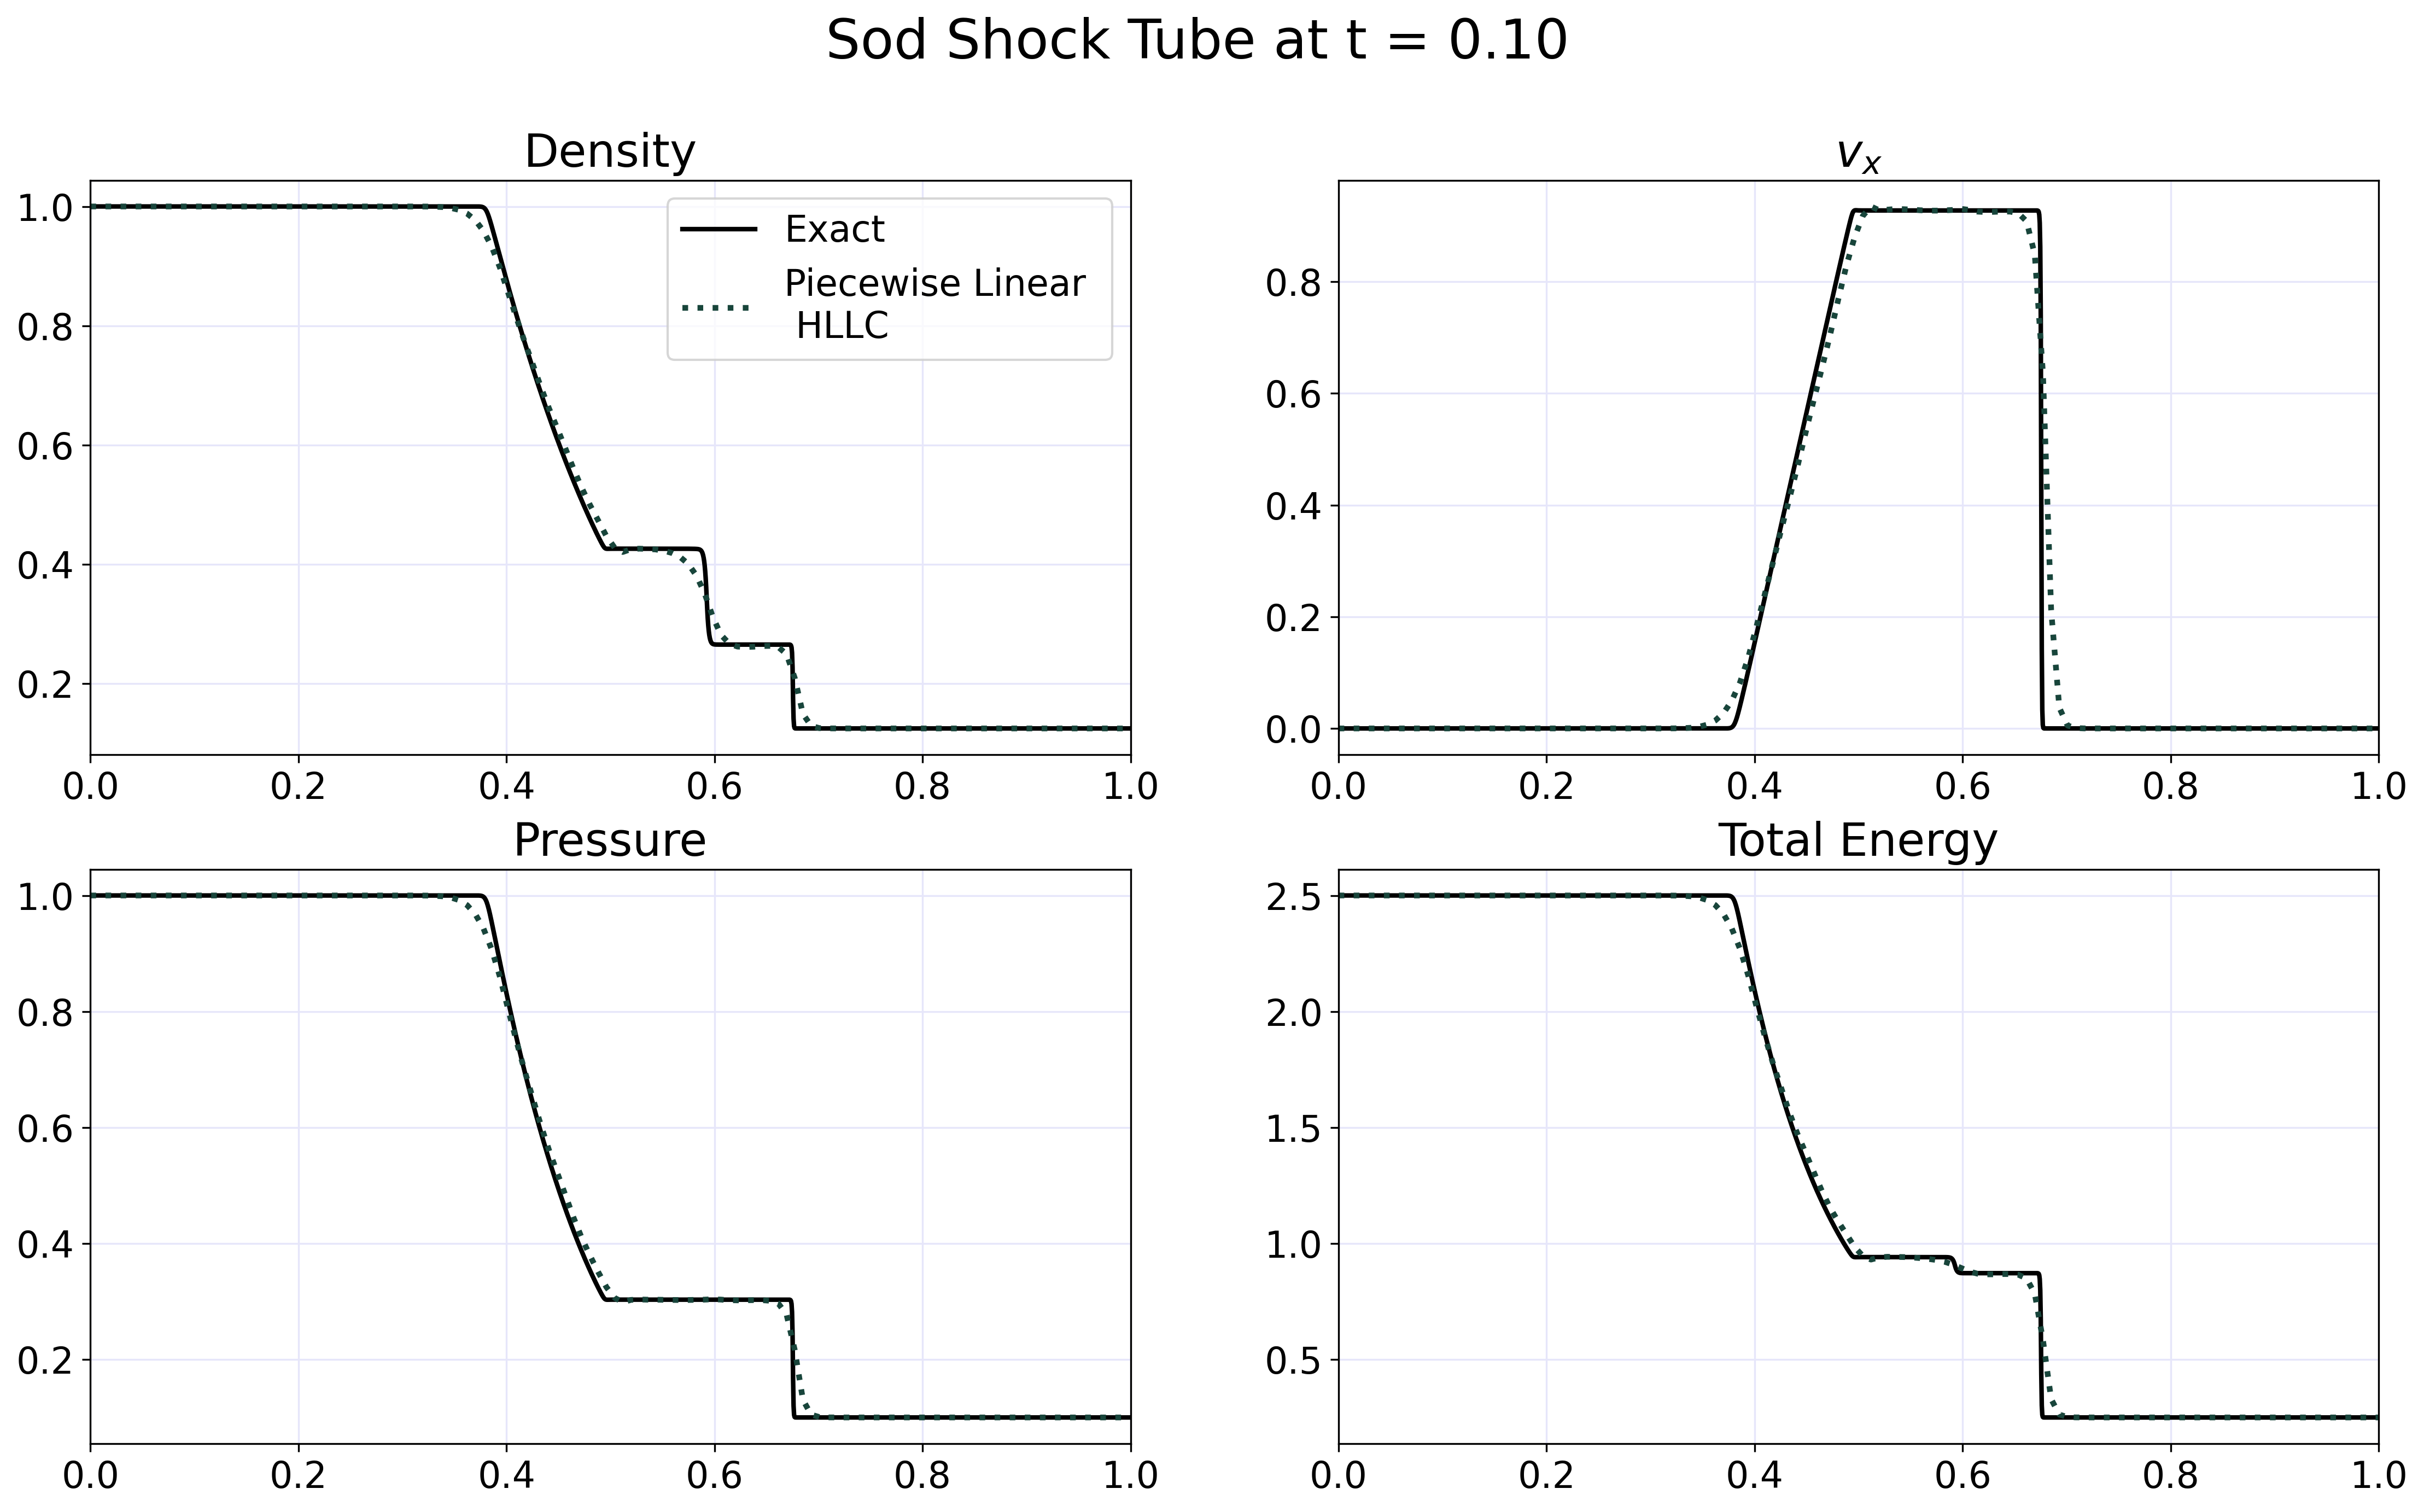

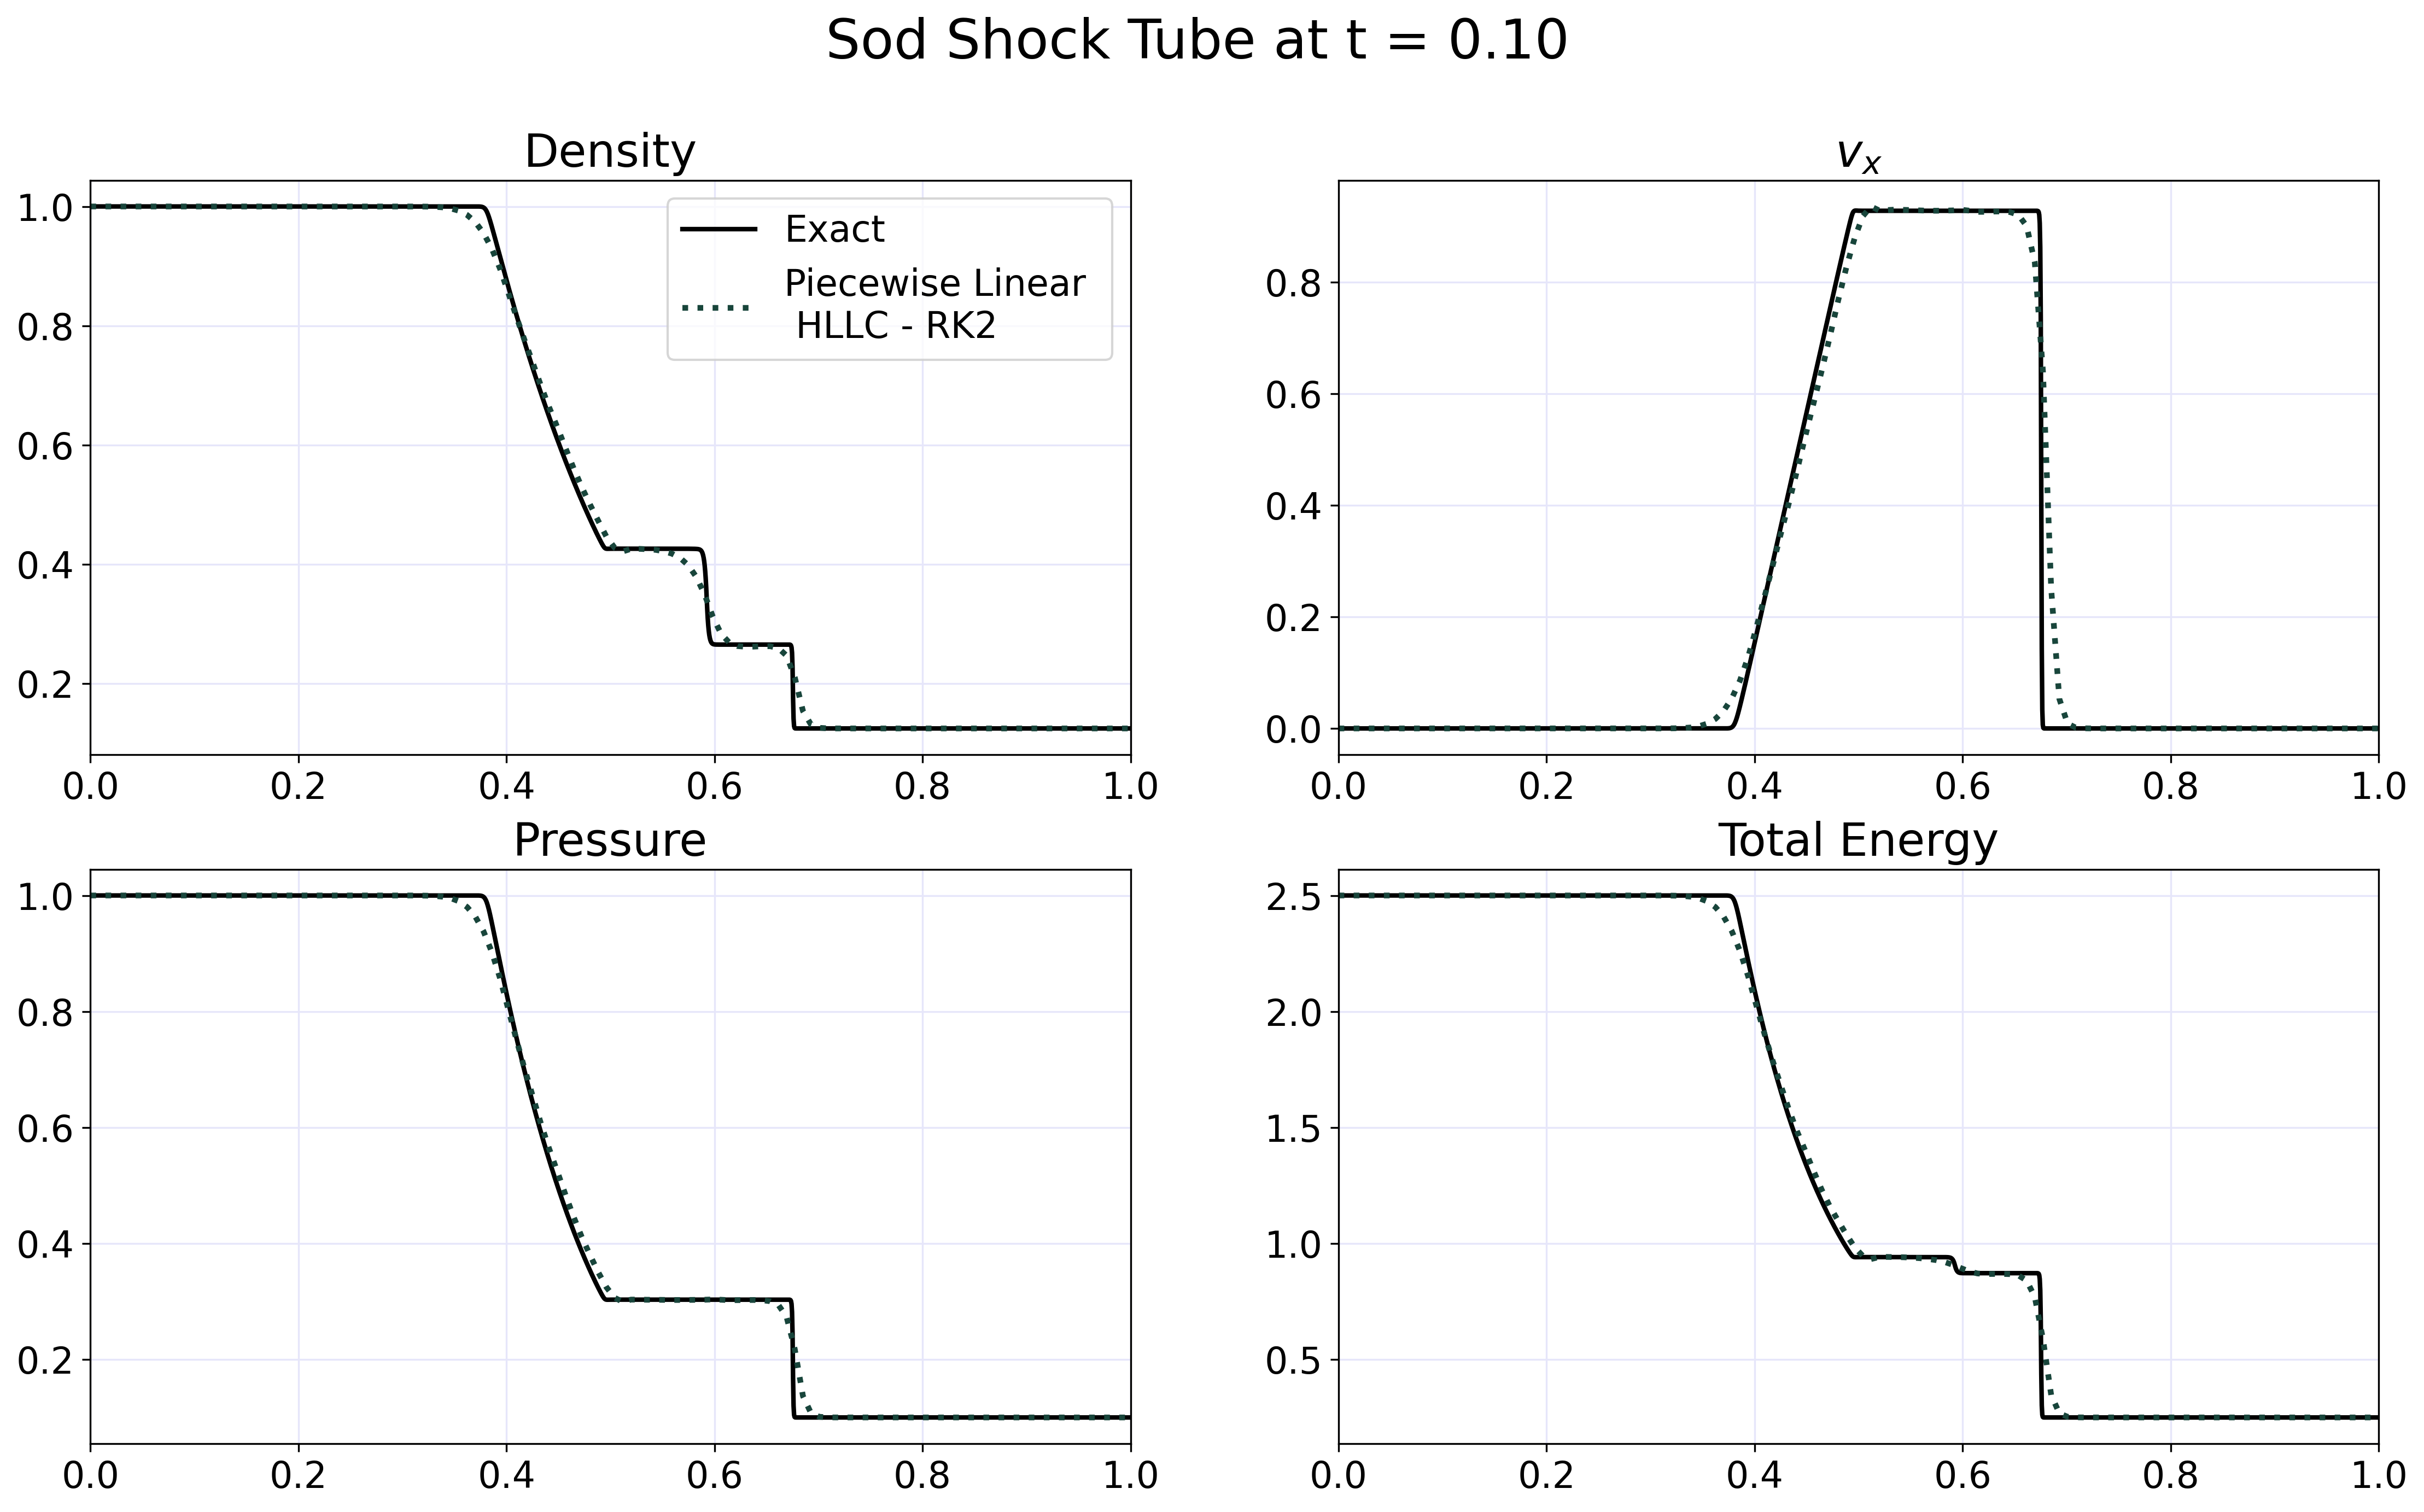

In [128]:
####################################################################################################
# Problem Parameters
####################################################################################################

DOFs_sod = 3    # conserved variables: ρ, ρu, ρE
nx    = 128     # number of interior cells (resolution; increase for sharper features, e.g. nx=512)
dx    = 1/nx    # cell width on unit domain [0, 1]
C     = 0.1     # CFL number — time step is dt = C * dx / max|u+c|; must be < 1 for stability
gamma = 1.4     # ratio of specific heats (diatomic ideal gas, e.g. air)
tf    = 0.1     # final simulation time (matches Zingale Figs. 8.9 and 8.10)

# Cell-center coordinate array for the interior domain [0, 1]
X = np.linspace(0, 1, nx)

####################################################################################################
# Build Ghosted Initial Condition Array
####################################################################################################

# Evaluate the Sod IC at each cell center; each call returns (ρ, ρu, ρE)^T for that point
U_IC_Sod = np.array([sods_shock_tube_IC(x, gamma) for x in X])   # shape (nx, DOFs)
U_IC_Sod = U_IC_Sod.T                                             # shape (DOFs, nx)

# Allocate the ghosted array and embed the interior IC; ghost cells will be filled by evolve()
U_ghost_IC_Sod = np.zeros((DOFs_sod, nx + 2*nghost))              # shape (DOFs, nx + 2*nghost)
U_ghost_IC_Sod[:, nghost:nghost+nx] = U_IC_Sod

####################################################################################################
# Evolve with HLL and HLLC Solvers (Piecewise Linear / 2nd-order Godunov)
####################################################################################################

# Run both solvers; Godunov_type=1 selects PLM reconstruction with minmod slope limiter
# U_Sol_Sod_g1_HLL,  all_solns_Sod_g1_HLL,  all_t_Sod_g1_HLL  = evolve(U_ghost_IC_Sod, nx, C, tf, gamma, Riemann_HLL,  Godunov_type=1)
U_Sol_Sod_g1_HLLC, all_solns_Sod_g1_HLLC, all_t_Sod_g1_HLLC             = evolve(U_ghost_IC_Sod, nx, C, tf, gamma, Riemann_HLLC, Godunov_type=1)
U_Sol_Sod_g1_HLLC_RK2, all_solns_Sod_g1_HLLC_RK2, all_t_Sod_g1_HLLC_RK2 = evolve(U_ghost_IC_Sod, nx, C, tf, gamma, Riemann_HLLC, Godunov_type=1, RK2=True)

####################################################################################################
# Plot Final Solutions vs. Exact
####################################################################################################

# HLL:
# plot_solution(X, U_Sol_Sod_g1_HLL,  tf, gamma, 'Sod', 'Piecewise Linear', 'HLL')

# HLLC:
plot_solution(X, U_Sol_Sod_g1_HLLC, tf, gamma, 'Sod', 'Piecewise Linear', 'HLLC')

# HLLC RK2:
plot_solution(X, U_Sol_Sod_g1_HLLC_RK2, tf, gamma, 'Sod', 'Piecewise Linear', 'HLLC - RK2')


# $\Downarrow$ Make a Movie $\Downarrow$
Takes ~10 min to run for n_points = 1024

In [129]:
#movie_maker(X, all_solns_Sod_g1, all_t_Sod_g1, gamma, 'Sod')